<a href="https://colab.research.google.com/github/Jes6241/IA2/blob/main/Practica_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A) Caminos DFS, BFA y A*

In [ ]:
import time
import tracemalloc
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# ── DEFINICIÓN DEL LABERINTO ──
# Matriz 2D donde 1 representa una Pared y 0 representa un Camino libre.
laberinto = [
    [1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1],
    [1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1],
    [1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1],
    [1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1],
    [1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1],
    [1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1],
    [1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1],
    [1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1],
    [1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1]
]

FILAS, COLS = len(laberinto), len(laberinto[0])
RAIZ, OBJETIVO = (0, 1), (14, 13) # Coordenadas (Fila, Columna) de inicio y fin

# ── FUNCIONES DE AYUDA ──

def obtener_vecinos(nodo):
    """
    Recibe un nodo (fila, columna).
    Revisa las 4 direcciones posibles (Abajo, Arriba, Derecha, Izquierda).
    Retorna una lista con las coordenadas vecinas que sean válidas (que estén dentro
    del mapa y que sean un 0, es decir, un camino).
    """
    f, c = nodo
    vecinos_validos = []
    for df, dc in [(1,0), (-1,0), (0,1), (0,-1)]:
        if 0 <= f+df < FILAS and 0 <= c+dc < COLS and laberinto[f+df][c+dc] == 0:
            vecinos_validos.append((f+df, c+dc))
    return vecinos_validos

def reconstruir(padre, actual):
    """
    Una vez que el algoritmo llega a la meta, esta función reconstruye el camino.
    Usa el diccionario 'padre' (que recuerda qué nodo descubrió a qué nodo)
    para caminar hacia atrás desde la meta hasta el inicio.
    Luego invierte la lista ([::-1]) para dar el camino desde el inicio a la meta.
    """
    camino = [actual]
    while actual in padre:
        actual = padre[actual]
        camino.append(actual)
    return camino[::-1]

def extraer_lista_visitados(matriz_visitados):
    """
    Convierte la matriz 2D de booleanos (True/False) en una lista simple de
    coordenadas (fila, columna) para que Matplotlib pueda dibujar los puntos celestes.
    """
    lista = []
    for f in range(FILAS):
        for c in range(COLS):
            if matriz_visitados[f][c]:
                lista.append((f, c))
    return lista


# ── ALGORITMOS DE BÚSQUEDA ──

def bfs(raiz, objetivo):
    """
    BÚSQUEDA EN ANCHURA (Breadth-First Search).
    Usa una COLA (FIFO: el primero en entrar es el primero en salir).
    Se expande en todas direcciones por igual, garantizando el camino más corto.
    """
    # Matriz para recordar por dónde ya pasamos (evita ciclos infinitos)
    visitado = [[False for _ in range(COLS)] for _ in range(FILAS)]
    visitado[raiz[0]][raiz[1]] = True

    cola = [raiz]
    padre = {}
    energia, mem_max = 0, 1

    while cola:
        mem_max = max(mem_max, len(cola))
        nodo = cola.pop(0) # Saca el PRIMER elemento (comportamiento de Cola)

        if nodo == objetivo: break # Si llegamos a la meta, terminamos.

        for v in obtener_vecinos(nodo):
            vf, vc = v
            if not visitado[vf][vc]:
                visitado[vf][vc] = True
                padre[v] = nodo
                cola.append(v) # Añade los vecinos al FINAL de la cola
                energia += 1

    camino = reconstruir(padre, objetivo) if objetivo in padre else []
    lista_visitados = extraer_lista_visitados(visitado)
    return camino, mem_max, energia, lista_visitados

def dfs(raiz, objetivo):
    """
    BÚSQUEDA EN PROFUNDIDAD (Depth-First Search).
    Usa una PILA (LIFO: el último en entrar es el primero en salir).
    Explora un solo camino hasta topar con pared, luego retrocede. No garantiza camino corto.
    """
    visitado = [[False for _ in range(COLS)] for _ in range(FILAS)]
    visitado[raiz[0]][raiz[1]] = True

    pila = [raiz]
    padre = {}
    energia, mem_max = 0, 1

    while pila:
        mem_max = max(mem_max, len(pila))
        nodo = pila.pop() # Saca el ÚLTIMO elemento (comportamiento de Pila)

        if nodo == objetivo: break

        for v in obtener_vecinos(nodo):
            vf, vc = v
            if not visitado[vf][vc]:
                visitado[vf][vc] = True
                padre[v] = nodo
                pila.append(v) # Añade los vecinos a la CIMA de la pila
                energia += 1

    camino = reconstruir(padre, objetivo) if objetivo in padre else []
    lista_visitados = extraer_lista_visitados(visitado)
    return camino, mem_max, energia, lista_visitados

def astar(raiz, objetivo):
    """
    ALGORITMO A* (A-Estrella).
    Búsqueda informada. Utiliza el costo real (G) + una heurística (H) para estimar
    qué camino es el mejor y priorizarlo.
    """
    g = {raiz: 0} # Costo real de pasos dados desde el inicio hasta el nodo

    # f = Costo real (g) + Costo estimado a la meta (Distancia Manhattan)
    f = {raiz: abs(raiz[0]-objetivo[0]) + abs(raiz[1]-objetivo[1])}

    padre = {}
    abierta = [raiz] # Lista de nodos por explorar
    cerrada_lista = [] # Nodos que ya exploramos y no debemos volver a mirar
    visitados_lista = [raiz] # Registro para pintar los puntos celestes

    energia, mem_max = 0, 1

    while abierta:
        mem_max = max(mem_max, len(abierta))

        # 1. Buscar manualmente el nodo en 'abierta' que tenga el menor costo 'f'
        cur = abierta[0]
        for nodo in abierta:
            if f[nodo] < f[cur]:
                cur = nodo

        # 2. Sacar 'cur' de la lista abierta (creando una nueva lista sin él)
        nueva_abierta = []
        for nodo in abierta:
            if nodo != cur:
                nueva_abierta.append(nodo)
        abierta = nueva_abierta

        # Marcar como explorado
        cerrada_lista.append(cur)

        if cur == objetivo: break # Llegamos a la meta

        # 3. Evaluar a los vecinos
        for v in obtener_vecinos(cur):
            if v in cerrada_lista: continue # Si ya lo evaluamos, lo ignoramos

            nuevo_g = g[cur] + 1 # Un paso más de costo real

            # Si este camino es mejor que otro que hayamos encontrado antes para 'v'
            if nuevo_g < g.get(v, float('inf')):
                g[v] = nuevo_g
                # Calculamos el nuevo 'f' sumando el 'g' más la distancia Manhattan a la meta
                f[v] = nuevo_g + abs(v[0]-objetivo[0]) + abs(v[1]-objetivo[1])
                padre[v] = cur

                # Registramos visualmente que pasamos por aquí
                if v not in visitados_lista:
                    visitados_lista.append(v)

                # Si el vecino no está en la lista de pendientes, lo agregamos
                if v not in abierta:
                    abierta.append(v)
                energia += 1

    camino = reconstruir(padre, objetivo) if objetivo in padre else []
    return camino, mem_max, energia, visitados_lista


# ── EJECUCIÓN Y GRÁFICOS ──

def ejecutar(nombre, func, *args):
    """
    Función envoltorio para correr un algoritmo midiendo su rendimiento.
    Usa time.perf_counter() para milisegundos exactos y tracemalloc para medir
    los bytes de memoria RAM utilizados.
    """
    tracemalloc.start()
    t0 = time.perf_counter()

    camino, mem_max, energia, visitados = func(*args) # Llama al algoritmo

    t1 = time.perf_counter()
    _, pico = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    return {'nombre': nombre, 'camino': camino, 'tiempo': (t1 - t0) * 1000,
            'mem_bytes': pico, 'energia': energia, 'encontrado': bool(camino),
            'visitados': visitados}

if __name__ == '__main__':
    # 1. Correr los 3 algoritmos
    resultados = [
        ejecutar('BFS', bfs, RAIZ, OBJETIVO),
        ejecutar('DFS', dfs, RAIZ, OBJETIVO),
        ejecutar('A*', astar, RAIZ, OBJETIVO)
    ]

    # 2. Imprimir tabla de métricas
    print(f"\n{'═'*55}\n{'Algoritmo':<8} {'Tiempo(ms)':>12} {'Mem(B)':>10} {'Energía':>10} {'Pasos':>7}\n{'-'*55}")
    for r in resultados:
        pasos = len(r['camino'])-1 if r['encontrado'] else '-'
        print(f"{r['nombre']:<8} {r['tiempo']:>12.4f} {r['mem_bytes']:>10} {r['energia']:>10} {str(pasos):>7}")
    print('═'*55)

    # 3. Imprimir respuesta teórica requerida
    print("\nComplejidad O(·) teórica de cada algoritmo:")
    print("  BFS: O(V + E) -> V = Vértices (celdas libres), E = Aristas (conexiones).")
    print("  DFS: O(V + E) -> Explora todos los nodos en el peor de los casos.")
    print("  A*:  O(b^d)   -> 'b' es el factor de ramificación y 'd' la profundidad de la meta.")
    print("═"*55)

    # 4. Dibujar los subplots con matplotlib
    fig, axes = plt.subplots(1, 3, figsize=(15, 6))
    cmap = ListedColormap(['#FFFFFF', '#CBB940']) # Blanco para camino, Mostaza para pared

    for ax, r in zip(axes, resultados):
        estado = "(OK)" if r['encontrado'] else "(Fallo)"
        ax.set_title(f"{r['nombre']} {estado}")

        ax.imshow(laberinto, cmap=cmap) # Dibuja la matriz

        # Dibuja los puntos celestes (nodos explorados/visitados)
        if r['visitados']:
            vx, vy = zip(*[(c[1], c[0]) for c in r['visitados']])
            ax.scatter(vx, vy, color='#64B5F6', s=45, alpha=0.8, zorder=1, label='Explorados')

        # Dibuja la línea roja continua (la ruta final encontrada)
        if r['camino']:
            xs, ys = zip(*[(c[1], c[0]) for c in r['camino']])
            ax.plot(xs, ys, color='#FF3333', lw=4, alpha=0.9, zorder=2, label='Ruta')

            # Puntos verde (Inicio) y azul (Meta)
            ax.plot(xs[0], ys[0], 'go', markersize=10, zorder=3)
            ax.plot(xs[-1], ys[-1], 'bo', markersize=10, zorder=3)

        ax.axis('off') # Quitar las reglas de coordenadas alrededor del dibujo

        if ax == axes[-1]:
            ax.legend(loc='lower right', fontsize=8)

    plt.tight_layout()
    plt.show()

B) A*


══════════════════════════════════════════════════════════════════════
Algoritmo            Tiempo(ms)     Mem(B)    Energía  Costo G
----------------------------------------------------------------------
A* (Manhattan)           7.0645      35544        235      198
A* (L2 Euclidiana)       7.6431      40167        236      198
══════════════════════════════════════════════════════════════════════


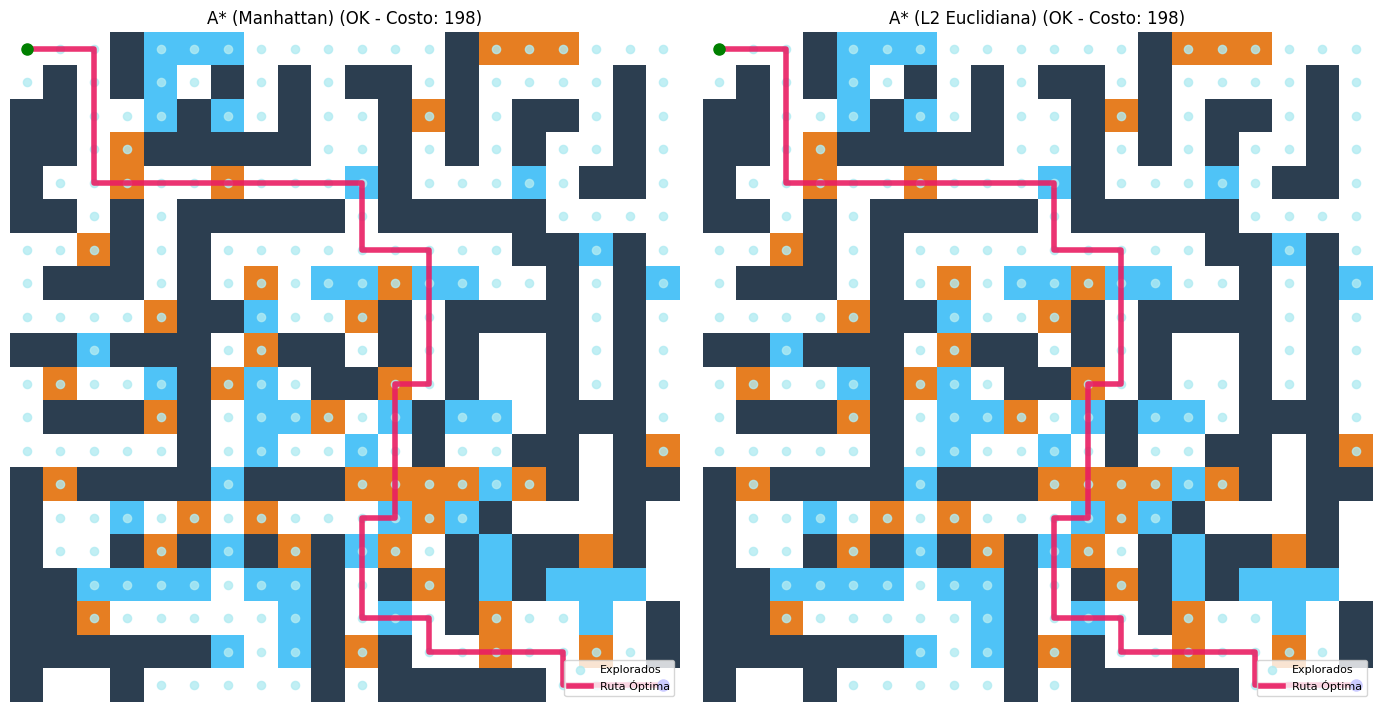

In [ ]:
import time
import tracemalloc
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# ── NUEVO LABERINTO MEJORADO (20x20) ──
# 0 = Transitable | 1 = Pared | 2 = Agua | 3 = Fuego
# - Sin bloques cuadrados gruesos de paredes.
# - Ríos y muros de fuego estratégicos.
laberinto = [
    [0, 0, 0, 1, 2, 2, 2, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 0, 0, 0],
    [0, 1, 0, 1, 2, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0],
    [1, 1, 0, 0, 2, 1, 2, 0, 1, 0, 0, 1, 3, 1, 0, 1, 1, 0, 1, 0],
    [1, 1, 0, 3, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0],
    [1, 0, 0, 3, 0, 0, 3, 0, 0, 0, 2, 1, 0, 0, 0, 2, 0, 1, 1, 0],
    [1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0],
    [0, 0, 3, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 2, 1, 0],
    [0, 1, 1, 1, 0, 1, 0, 3, 0, 2, 2, 3, 2, 2, 0, 0, 1, 0, 1, 2],
    [0, 0, 0, 0, 3, 1, 1, 2, 0, 0, 3, 1, 0, 1, 1, 1, 1, 0, 1, 0],
    [1, 1, 2, 1, 1, 1, 0, 3, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0],
    [0, 3, 0, 0, 2, 1, 3, 2, 0, 1, 1, 3, 0, 1, 0, 0, 1, 0, 1, 0],
    [0, 1, 1, 1, 3, 1, 0, 2, 2, 3, 0, 2, 1, 2, 2, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 2, 0, 1, 0, 0, 1, 1, 0, 1, 3],
    [1, 3, 1, 1, 1, 1, 2, 1, 1, 1, 3, 3, 3, 3, 2, 3, 1, 0, 1, 1],
    [1, 0, 0, 2, 0, 3, 0, 3, 0, 0, 0, 2, 3, 2, 1, 0, 0, 0, 1, 0],
    [1, 0, 0, 1, 3, 1, 2, 1, 3, 1, 2, 3, 0, 1, 2, 1, 1, 3, 1, 0],
    [1, 1, 2, 2, 2, 2, 0, 2, 2, 1, 0, 1, 3, 1, 2, 1, 2, 2, 2, 0],
    [1, 1, 3, 0, 0, 0, 0, 0, 2, 1, 0, 2, 0, 1, 3, 0, 0, 2, 0, 1],
    [1, 1, 1, 1, 1, 1, 2, 0, 2, 1, 3, 1, 0, 0, 3, 0, 0, 3, 0, 1],
    [1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0]
]

FILAS, COLS = len(laberinto), len(laberinto[0])
RAIZ, OBJETIVO = (0, 0), (19, 19)

# ── FUNCIONES DE AYUDA ──
def obtener_vecinos_validos(nodo):
    f, c = nodo
    vecinos = []
    for df, dc in [(1,0), (-1,0), (0,1), (0,-1)]:
        nf, nc = f+df, c+dc
        if 0 <= nf < FILAS and 0 <= nc < COLS and laberinto[nf][nc] != 1:
            vecinos.append((nf, nc))
    return vecinos

def reconstruir(padre, actual):
    camino = [actual]
    while actual in padre:
        actual = padre[actual]
        camino.append(actual)
    return camino[::-1]

# ── A* MODIFICADO (Misma lógica, sin .add() ni .remove()) ──
def astar_costos(raiz, objetivo, tipo_heuristica):
    X = 1

    def calcular_h(nodo):
        if tipo_heuristica == 'manhattan':
            return abs(nodo[0] - objetivo[0]) + abs(nodo[1] - objetivo[1])
        else: # Euclidiana (L2)
            return ((nodo[0] - objetivo[0])**2 + (nodo[1] - objetivo[1])**2)**0.5

    g = {raiz: 0}
    f = {raiz: calcular_h(raiz)}
    padre = {}

    abierta = [raiz]
    cerrada_lista = []
    visitados_lista = [raiz]
    energia, mem_max = 0, 1

    while abierta:
        mem_max = max(mem_max, len(abierta))

        cur = abierta[0]
        for nodo in abierta:
            if f[nodo] < f[cur]:
                cur = nodo

        # Simulación de .remove()
        nueva_abierta = []
        for nodo in abierta:
            if nodo != cur:
                nueva_abierta.append(nodo)
        abierta = nueva_abierta

        cerrada_lista.append(cur)

        if cur == objetivo: break

        for v in obtener_vecinos_validos(cur):
            if v in cerrada_lista: continue

            tipo = laberinto[v[0]][v[1]]
            mov_horizontal = (abs(v[1] - cur[1]) == 1)
            mov_vertical = (abs(v[0] - cur[0]) == 1)

            if tipo == 0:
                costo_paso = X
            elif tipo == 2:
                costo_paso = X + 10
            elif tipo == 3:
                if mov_horizontal:
                    costo_paso = X + 20
                elif mov_vertical:
                    costo_paso = (2 * X) + 15

            nuevo_g = g[cur] + costo_paso

            if nuevo_g < g.get(v, float('inf')):
                g[v] = nuevo_g
                f[v] = nuevo_g + calcular_h(v)
                padre[v] = cur

                if v not in visitados_lista: visitados_lista.append(v)
                if v not in abierta: abierta.append(v)
                energia += 1

    camino = reconstruir(padre, objetivo) if objetivo in padre else []
    costo_total = g.get(objetivo, 0)
    return camino, mem_max, energia, visitados_lista, costo_total

# ── EJECUCIÓN Y GRÁFICOS ──
def ejecutar(nombre, tipo_heuristica):
    tracemalloc.start()
    t0 = time.perf_counter()
    camino, mem_max, energia, visitados, costo = astar_costos(RAIZ, OBJETIVO, tipo_heuristica)
    t1 = time.perf_counter()
    _, pico = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return {'nombre': nombre, 'camino': camino, 'tiempo': (t1 - t0) * 1000,
            'mem_bytes': pico, 'energia': energia, 'costo': costo,
            'encontrado': bool(camino), 'visitados': visitados}

if __name__ == '__main__':
    resultados = [
        ejecutar('A* (Manhattan)', 'manhattan'),
        ejecutar('A* (L2 Euclidiana)', 'euclidiana')
    ]

    print(f"\n{'═'*70}\n{'Algoritmo':<20} {'Tiempo(ms)':>10} {'Mem(B)':>10} {'Energía':>10} {'Costo G':>8}\n{'-'*70}")
    for r in resultados:
        print(f"{r['nombre']:<20} {r['tiempo']:>10.4f} {r['mem_bytes']:>10} {r['energia']:>10} {r['costo']:>8}")
    print('═'*70)

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    # Colores visuales
    cmap = ListedColormap(['#FFFFFF', '#2C3E50', '#4FC3F7', '#E67E22'])

    for ax, r in zip(axes, resultados):
        estado = f"(OK - Costo: {r['costo']})" if r['encontrado'] else "(Fallo)"
        ax.set_title(f"{r['nombre']} {estado}")

        ax.imshow(laberinto, cmap=cmap)

        # Puntos celestes
        if r['visitados']:
            vx, vy = zip(*[(c[1], c[0]) for c in r['visitados']])
            ax.scatter(vx, vy, color='#B2EBF2', s=35, alpha=0.8, zorder=1, label='Explorados')

        # Ruta Roja
        if r['camino']:
            xs, ys = zip(*[(c[1], c[0]) for c in r['camino']])
            ax.plot(xs, ys, color='#E91E63', lw=4, alpha=0.9, zorder=2, label='Ruta Óptima')

            ax.plot(xs[0], ys[0], 'go', markersize=8, zorder=3)
            ax.plot(xs[-1], ys[-1], 'bo', markersize=8, zorder=3)

        ax.axis('off')
        ax.legend(loc='lower right', fontsize=8)

    plt.tight_layout()
    plt.show()

C) Mapa con A*

In [ ]:
# ── 0. INSTALAR LIBRERÍAS EN COLAB ──
!pip install osmnx folium -q

import osmnx as ox
import folium
import time

# ── 1. DESCARGAR EL MAPA (Centro Histórico CDMX) ──
print("Descargando el mapa del Centro Histórico de la CDMX (Zócalo)...")
# Tomamos el Zócalo y 1000 metros (1 km) a la redonda
lugar = "Zócalo, Ciudad de México, Mexico"
G = ox.graph_from_address(lugar, dist=1000, network_type="walk")
print(f"¡Mapa descargado! Tiene {len(G.nodes)} intersecciones (nodos peatonales).")

# ── 2. SELECCIONAR ORIGEN Y DESTINO ──
nodos_lista = list(G.nodes)
# Elegimos dos puntos distantes en la lista para que la ruta cruce gran parte del mapa
origen = nodos_lista[50]
destino = nodos_lista[-50]

# ── 3. FUNCIONES DE AYUDA (100% Manuales) ──
def heuristica_gps(nodo_actual, nodo_meta):
    """ Distancia en línea recta en metros aprox """
    x1 = G.nodes[nodo_actual]['x']
    y1 = G.nodes[nodo_actual]['y']
    x2 = G.nodes[nodo_meta]['x']
    y2 = G.nodes[nodo_meta]['y']
    distancia_grados = ((x1 - x2)**2 + (y1 - y2)**2)**0.5
    return distancia_grados * 111000

def reconstruir(padre, actual):
    camino = [actual]
    while actual in padre:
        actual = padre[actual]
        camino.append(actual)
    return camino[::-1]

# ── 4. A* MANUAL (Sin trampas de librerías para la lógica) ──
def astar_mapa_real(origen, destino):
    g = {origen: 0}
    f = {origen: heuristica_gps(origen, destino)}
    padre = {}

    abierta = [origen]
    cerrada_lista = [] # Estos serán nuestros puntos celestes

    while abierta:
        cur = abierta[0]
        for nodo in abierta:
            if f[nodo] < f[cur]:
                cur = nodo

        # Simulación manual de .remove()
        nueva_abierta = []
        for nodo in abierta:
            if nodo != cur:
                nueva_abierta.append(nodo)
        abierta = nueva_abierta

        cerrada_lista.append(cur)

        if cur == destino:
            break

        for vecino in G.neighbors(cur):
            ya_explorado = False
            for n in cerrada_lista:
                if n == vecino:
                    ya_explorado = True
                    break
            if ya_explorado: continue

            # Obtener distancia real de la calle en metros (¡aquí está la respuesta a tu pregunta!)
            datos_calle = G.get_edge_data(cur, vecino)
            min_dist = float('inf')
            for key in datos_calle:
                dist = datos_calle[key].get('length', 10) # Metros reales de esa cuadra
                if dist < min_dist:
                    min_dist = dist

            nuevo_g = g[cur] + min_dist

            if nuevo_g < g.get(vecino, float('inf')):
                g[vecino] = nuevo_g
                f[vecino] = nuevo_g + heuristica_gps(vecino, destino)
                padre[vecino] = cur

                en_abierta = False
                for n in abierta:
                    if n == vecino:
                        en_abierta = True
                        break

                if not en_abierta:
                    abierta.append(vecino)

    camino = reconstruir(padre, destino) if destino in padre else []
    distancia_total = g.get(destino, 0)

    return camino, distancia_total, cerrada_lista

# ── 5. EJECUCIÓN Y MAPA DINÁMICO (FOLIUM) ──
print("\nCalculando la ruta óptima con A* en el Centro de CDMX...")
t0 = time.time()
ruta_optima, metros, nodos_visitados = astar_mapa_real(origen, destino)
t1 = time.time()

if ruta_optima:
    print(f"\n{'═'*50}")
    print(f"¡Ruta encontrada exitosamente en {round((t1-t0)*1000, 2)} ms!")
    print(f"Esquinas/Intersecciones exploradas (puntos celestes): {len(nodos_visitados)}")
    print(f"Distancia total a caminar: {round(metros, 2)} metros.")
    print(f"{'═'*50}\n")

    print("Generando mapa interactivo... (Haz zoom para ver las calles de la CDMX)")

    coordenadas_ruta = []
    for nodo in ruta_optima:
        lat = G.nodes[nodo]['y']
        lon = G.nodes[nodo]['x']
        coordenadas_ruta.append([lat, lon])

    # Mapa oscuro para resaltar las calles y los puntos
    centro_mapa = coordenadas_ruta[len(coordenadas_ruta)//2]
    mapa_dinamico = folium.Map(location=centro_mapa, zoom_start=15, tiles="CartoDB dark_matter")

    # ── DIBUJAR PUNTOS CELESTES (Nodos Explorados) ──
    for nodo in nodos_visitados:
        lat = G.nodes[nodo]['y']
        lon = G.nodes[nodo]['x']
        folium.CircleMarker(
            location=[lat, lon],
            radius=2,               # Tamaño del punto un poco más fino para que se vea elegante
            color="#00BFFF",        # Celeste
            fill=True,
            fill_color="#00BFFF",
            fill_opacity=0.6,
            weight=0
        ).add_to(mapa_dinamico)

    # ── DIBUJAR LÍNEA DE LA RUTA (Roja) ──
    folium.PolyLine(
        coordenadas_ruta,
        color="#FF3333", # Rojo
        weight=5,        # Grosor
        opacity=0.9
    ).add_to(mapa_dinamico)

    # Marcadores de Inicio y Fin
    folium.Marker(coordenadas_ruta[0], popup="Inicio", icon=folium.Icon(color="green", icon="play")).add_to(mapa_dinamico)
    folium.Marker(coordenadas_ruta[-1], popup="Meta", icon=folium.Icon(color="red", icon="flag")).add_to(mapa_dinamico)

else:
    print("No se encontró una ruta posible entre esos puntos.")

# Mostrar el mapa
mapa_dinamico

Descargando el mapa del Centro Histórico de la CDMX (Zócalo)...
¡Mapa descargado! Tiene 1247 intersecciones (nodos peatonales).

Calculando la ruta óptima con A* en el Centro de CDMX...

══════════════════════════════════════════════════
¡Ruta encontrada exitosamente en 13.47 ms!
Esquinas/Intersecciones exploradas (puntos celestes): 411
Distancia total a caminar: 2476.04 metros.
══════════════════════════════════════════════════

Generando mapa interactivo... (Haz zoom para ver las calles de la CDMX)
